In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
df = pd.read_csv("Unemployment_Rate_upto_11_2020.csv")
display(df.head())
print("\nDataset Overview:")
df.info()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Region.1,longitude,latitude
0,Andhra Pradesh,31-01-2020,M,5.48,16635535,41.02,South,15.9129,79.74
1,Andhra Pradesh,29-02-2020,M,5.83,16545652,40.90,South,15.9129,79.74
2,Andhra Pradesh,31-03-2020,M,5.79,15881197,39.18,South,15.9129,79.74
3,Andhra Pradesh,30-04-2020,M,20.51,11336911,33.10,South,15.9129,79.74
4,Andhra Pradesh,31-05-2020,M,17.43,12988845,36.46,South,15.9129,79.74



Dataset Overview:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 267 entries, 0 to 266
Data columns (total 9 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    267 non-null    object 
 1    Date                                     267 non-null    object 
 2    Frequency                                267 non-null    object 
 3    Estimated Unemployment Rate (%)          267 non-null    float64
 4    Estimated Employed                       267 non-null    int64  
 5    Estimated Labour Participation Rate (%)  267 non-null    float64
 6   Region.1                                  267 non-null    object 
 7   longitude                                 267 non-null    float64
 8   latitude                                  267 non-null    float64
dtypes: float64(4), int64(1), object(4)
memory usage: 18.9+ KB


In [14]:
print("Column Names:", df.columns)
df.columns = df.columns.str.strip()
df.rename(columns={
    "Estimated Unemployment Rate (%)": "Unemployment Rate",
    "Estimated Employed": "Employed",
    "Estimated Labour Participation Rate (%)": "Labour Participation Rate"
}, inplace=True)
if "Date" in df.columns:
    df["Date"] = pd.to_datetime(df["Date"], errors='coerce', dayfirst=True)
else:
    print("Error: 'Date' column not found! Available columns:", df.columns)
print("\nMissing Values:\n", df.isnull().sum())
print("\nUnemployment Rate Statistics:\n", df["Unemployment Rate"].describe())
max_unemployment = df[df["Unemployment Rate"] == df["Unemployment Rate"].max()]
print("\nHighest Unemployment Period:\n", max_unemployment)
min_unemployment = df[df["Unemployment Rate"] == df["Unemployment Rate"].min()]
print("\nLowest Unemployment Period:\n", min_unemployment)


Column Names: Index(['Region', 'Date', 'Frequency', 'Unemployment Rate', 'Employed',
       'Labour Participation Rate', 'Region.1', 'longitude', 'latitude'],
      dtype='object')

Missing Values:
 Region                       0
Date                         0
Frequency                    0
Unemployment Rate            0
Employed                     0
Labour Participation Rate    0
Region.1                     0
longitude                    0
latitude                     0
dtype: int64

Unemployment Rate Statistics:
 count    267.000000
mean      12.236929
std       10.803283
min        0.500000
25%        4.845000
50%        9.650000
75%       16.755000
max       75.850000
Name: Unemployment Rate, dtype: float64

Highest Unemployment Period:
          Region       Date Frequency  Unemployment Rate  Employed  \
172  Puducherry 2020-04-30         M              75.85    117542   

     Labour Participation Rate Region.1  longitude  latitude  
172                       39.3    South    1

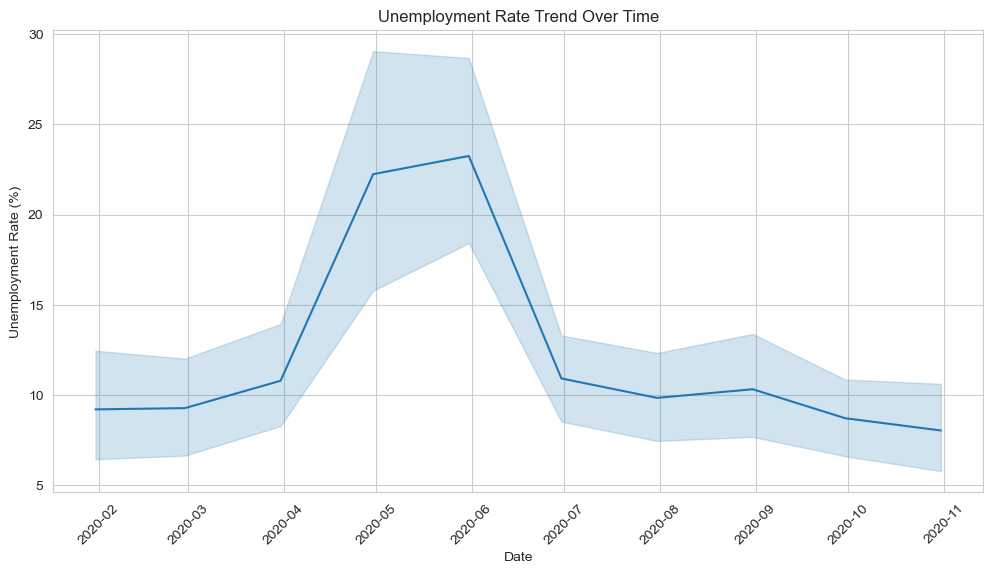

In [21]:
plt.figure(figsize=(12, 6))
sns.lineplot(x="Date", y="Unemployment Rate", data=df)
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")
plt.title("Unemployment Rate Trend Over Time")
plt.xticks(rotation=45)
plt.show()


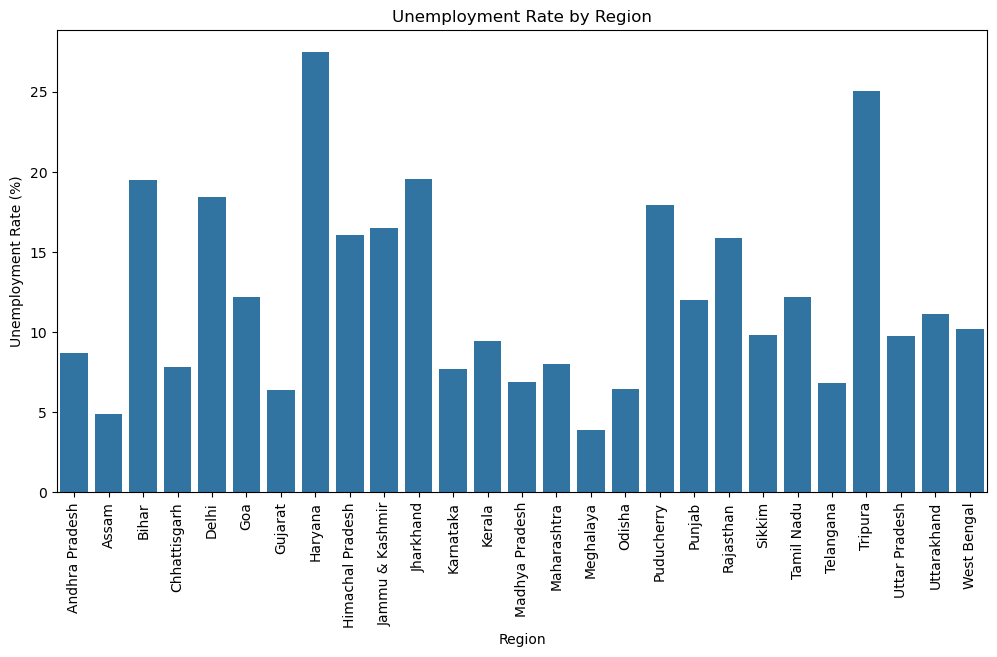

In [17]:
plt.figure(figsize=(12, 6))
sns.barplot(x="Region", y="Unemployment Rate", data=df, errorbar=None)  
plt.xticks(rotation=90)
plt.xlabel("Region")
plt.ylabel("Unemployment Rate (%)")
plt.title("Unemployment Rate by Region")
plt.show()